# 沐曦 GPU 运行 NV-Reason-CXR 说明文档

[NV-Reason-CXR](https://github.com/NVIDIA-Medtech/NV-Reason-CXR) 是面向正位胸部 X 光图像推理的视觉语言模型，模型卡见 [nvidia/NV-Reason-CXR-3B](https://huggingface.co/nvidia/NV-Reason-CXR-3B)。上游代码仓库采用 Apache-2.0 License，许可证全文见同目录 `LICENSE`。模型权重是单独的模型资产，不随本教程分发；运行前请由用户自行从模型卡下载并确认其适用条款，放置到后续参数单元指定的本地目录。

本教程复现逐步推理、异常与支持设备识别、系统性解剖检查、鉴别考虑、随访/临床相关性、结构化报告形态文本和澄清问答。输入为 NVIDIA Space 发布的胸片样例，未提供独立 ground truth。模型输出可能包含错误或遗漏，仅用于非商业研究、教育与工程验证，不用于诊断、治疗、分诊、临床决策、患者服务或监管提交。

## 1. 安装

### 1.1 沐曦容器

使用包含 MACA 版 PyTorch 的沐曦基础镜像；设备节点、共享目录和镜像名称按目标机器替换：

```bash
docker run -it --name nv-reason-cxr-notebook --device=/dev/mxcd --group-add video --shm-size=16G --ulimit memlock=-1 --ulimit stack=67108864 -v /workspace:/workspace <MACA_PYTORCH_IMAGE> /bin/bash
```

### 1.2 依赖与资产

```bash
python -m pip install transformers tokenizers safetensors accelerate Pillow huggingface-hub
huggingface-cli download nvidia/NV-Reason-CXR-3B --local-dir /workspace/models/nvidia--NV-Reason-CXR-3B
```

请用户自行从 [NV-Reason-CXR-3B 模型卡](https://huggingface.co/nvidia/NV-Reason-CXR-3B) 下载完整模型目录，并确认模型权重及其依赖资产的适用许可。将本地目录放到参数单元的 `NV_REASON_CXR_MODEL_PATH` 所指位置；Notebook 不自动下载或修改模型权重。

### 1.3 运行参数

以下参数是模型、输入图像、校验、预处理和推理的唯一入口，可通过环境变量替换模型和图片位置。模型权重必须由用户预先下载，本 Notebook 不自动下载或修改权重。

In [1]:
import os
from pathlib import Path

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
os.environ.setdefault('HF_HUB_OFFLINE', '1')
os.environ.setdefault('TRANSFORMERS_OFFLINE', '1')

MODEL_PATH = Path(os.environ.get('NV_REASON_CXR_MODEL_PATH', '/workspace/models/nvidia--NV-Reason-CXR-3B'))
IMAGE_PATH = Path(os.environ.get('NV_REASON_CXR_IMAGE_PATH', '/workspace/assets/35.jpg'))
IMAGE_URL = 'https://huggingface.co/spaces/nvidia/nv-reason-cxr/resolve/a22b517e09748f657baf16da038878f1030e60f5/example_images/35.jpg'
IMAGE_SHA256 = 'a60351b5f3a9987c0b110e48e1dcdc8a165eb9c56a9a0d416cd76a043aad8a7f'
DEVICE = 'cuda:0'
MAX_NEW_TOKENS = 2048

TASKS = {
    '逐步推理': 'Explain your step-by-step reasoning for a medical student reviewing this chest X-ray.',
    '异常与支持设备': 'Find abnormalities and support devices.',
    '系统性解剖检查': 'Systematically review the airway, lungs, pleura, heart and mediastinum, upper abdomen, and bones. Identify normal and abnormal findings and any support devices.',
    '鉴别考虑': 'Provide differential diagnoses for the findings, with reasoning.',
    '随访与临床相关性': 'What follow-up imaging or clinical correlation would be appropriate for the findings?',
    '结构化报告形态文本': 'Provide a radiology report with headings and consistent structure.',
    '澄清问答': 'Clarify which observations most strongly support your answer and which remain uncertain.',
}

print('Model:', MODEL_PATH)
print('Image:', IMAGE_PATH)
print('Device:', DEVICE)
print('Tasks:', list(TASKS))

Model: /models/nvidia--NV-Reason-CXR-3B
Image: /workspace/assets/35.jpg
Device: cuda:0
Tasks: ['逐步推理', '异常与支持设备', '系统性解剖检查', '鉴别考虑', '随访与临床相关性', '结构化报告形态文本', '澄清问答']


PyTorch: 2.6.0+metax3.8.0.7
Transformers: 5.12.1
GPU: MetaX C500
GPU memory: 60.9/63.6 GiB free
Image source: https://huggingface.co/spaces/nvidia/nv-reason-cxr/resolve/a22b517e09748f657baf16da038878f1030e60f5/example_images/35.jpg
Image SHA-256: a60351b5f3a9987c0b110e48e1dcdc8a165eb9c56a9a0d416cd76a043aad8a7f
Image size: (512, 512)


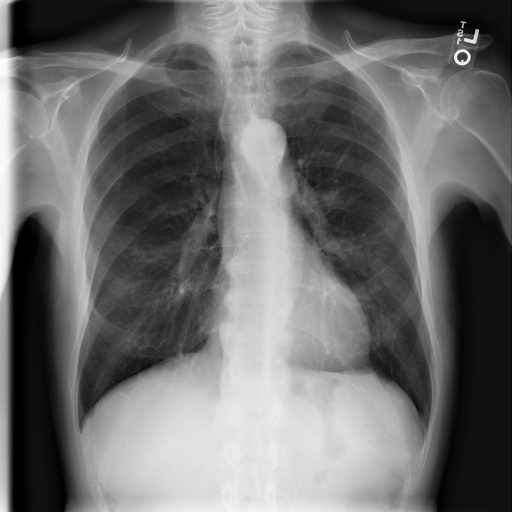

In [2]:
import hashlib
import urllib.request
from PIL import Image
import torch
import transformers

if not torch.cuda.is_available():
    raise RuntimeError('未检测到沐曦 GPU，请检查 MACA 容器设备映射。')
if not MODEL_PATH.is_dir():
    raise FileNotFoundError(f'模型目录不存在：{MODEL_PATH}')
if not IMAGE_PATH.exists():
    IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

digest = hashlib.sha256(IMAGE_PATH.read_bytes()).hexdigest()
if digest != IMAGE_SHA256:
    raise ValueError(f'胸片 SHA-256 不匹配：{digest}')
with Image.open(IMAGE_PATH) as source_image:
    image = source_image.convert('RGB')

free_memory, total_memory = torch.cuda.mem_get_info(0)
print('PyTorch:', torch.__version__)
print('Transformers:', transformers.__version__)
print('GPU:', torch.cuda.get_device_name(0))
print(f'GPU memory: {free_memory / 2**30:.1f}/{total_memory / 2**30:.1f} GiB free')
print('Image source:', IMAGE_URL)
print('Image SHA-256:', digest)
print('Image size:', image.size)
display(image)

In [3]:
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

from transformers import AutoModelForImageTextToText, AutoProcessor
from transformers.utils import logging as transformers_logging

transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()

load_options = {'local_files_only': True, 'trust_remote_code': False}
try:
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_PATH, dtype=torch.bfloat16, **load_options
    )
except TypeError:
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_PATH, torch_dtype=torch.bfloat16, **load_options
    )
model = model.eval().to(DEVICE)
processor = AutoProcessor.from_pretrained(MODEL_PATH, use_fast=True, **load_options)
model.generation_config.do_sample = False
model.generation_config.temperature = None
model.generation_config.top_p = None
print('Model loaded on:', next(model.parameters()).device)
print('Dtype:', next(model.parameters()).dtype)

Model loaded on: cuda:0
Dtype: torch.bfloat16


## 2. 任务推理

每个任务在独立代码单元中直接调用模型，单元格输出即为该任务的原始回答。鉴别、随访、报告形态文本和澄清任务会在同一张胸片及“异常与支持设备”回答的上下文中继续提问；输出不代表临床结论。

In [4]:
messages = [{
    'role': 'user',
    'content': [
        {'type': 'image', 'image': image},
        {'type': 'text', 'text': TASKS['逐步推理']},
    ],
}]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
    )
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
response = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0].strip()
print('## 逐步推理')
print(response)

## 逐步推理
<think> We'll begin with the quality of this PA chest x-ray. As you can see, part of the right scapula is superimposed on the lung field, which diminishes the quality of the scan. It is acceptable but slightly suboptimal imaging technique. A similar pattern is visible on the left side. If there's an infiltrate in the right upper lobe, for example, it could easily be hidden behind this scapular superimposition.

We're going to begin with evaluation of the central airways. The trachea is patent and it is slightly pushed by the aortic arch, which appears calcified and prominent. This patient probably has a history of hypertension. Similarly, the left main bronchus is pushed toward the right side laterally, but it is patent, and the right mainstem bronchus is also patent.

Now we are checking the right upper lobe and portions of the right middle lobe. The aeration is fine. I don't see any infiltrate opacity or nodule or a mass. And also there is no evidence of pneumothorax. And at 

In [5]:
messages = [{
    'role': 'user',
    'content': [
        {'type': 'image', 'image': image},
        {'type': 'text', 'text': TASKS['异常与支持设备']},
    ],
}]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
    )
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
initial_response = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0].strip()
print('## 异常与支持设备')
print(initial_response)

## 异常与支持设备
<think> We'll begin with the quality of this PA chest x-ray. As you can see, part of the right scapula is superimposed on the lung field, which diminishes the quality of the scan. It is acceptable but slightly suboptimal imaging technique. A similar pattern is visible on the left side. If there's an infiltrate in the right upper lobe, for example, it could easily be hidden behind this scapular superimposition.

We're going to begin with evaluation of the central airways. The trachea is patent and it is slightly pushed by the aortic arch, which appears calcified and prominent. This patient probably has a history of hypertension. Similarly, the left main bronchus is pushed toward the right side laterally, but it is patent, and the right mainstem bronchus is also patent.

Now we are checking the right upper lobe and portions of the right middle lobe. The aeration is fine. I don't see any infiltrate opacity or nodule or a mass. And also there is no evidence of pneumothorax. And 

In [6]:
messages = [{
    'role': 'user',
    'content': [
        {'type': 'image', 'image': image},
        {'type': 'text', 'text': TASKS['系统性解剖检查']},
    ],
}]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
    )
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
response = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0].strip()
print('## 系统性解剖检查')
print(response)

## 系统性解剖检查
<think> We'll begin with the quality of this PA chest x-ray. As you can see, part of the right scapula is superimposed on the lung field, which diminishes the quality of the scan. It is acceptable but slightly suboptimal imaging technique. A similar pattern is visible on the left side. If there's an infiltrate in the right upper lobe, for example, it could easily be hidden behind this scapular superimposition.

We're going to begin with evaluation of the central airways. The trachea is patent and it is slightly pushed by the aortic arch, which appears calcified and prominent. This patient probably has a history of hypertension. Similarly, the left main bronchus is pushed toward the right side laterally, but it is patent, and the right mainstem bronchus is also patent.

Now we are checking the right upper lobe and portions of the right middle lobe. The aeration is fine. I don't see any infiltrate opacity or nodule or a mass. And also there is no evidence of pneumothorax. And 

In [7]:
messages = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': TASKS['异常与支持设备']},
        ],
    },
    {'role': 'assistant', 'content': initial_response},
    {'role': 'user', 'content': TASKS['鉴别考虑']},
]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
    )
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
response = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0].strip()
print('## 鉴别考虑')
print(response)

## 鉴别考虑
<think> The question asks me to list possible causes for the observed normal lung fields and a prominent calcified aortic arch. I must consider conditions that produce a normal pulmonary appearance and aortic changes.  First, I note that the lungs are clear with no infiltrates, masses, or effusions, suggesting no acute pulmonary pathology. Second, the aortic arch is markedly calcified, which is typical in patients with long-standing hypertension.  Other potential considerations include age-related atherosclerotic disease, connective-tissue disorders such as Marfan syndrome (though rare), and prior radiation therapy, but these usually have distinct imaging patterns.  Thus, the most plausible differentials are chronic hypertension-related atherosclerosis and age-related vascular calcification; no acute pulmonary disease is present. </think>
<answer> Likely chronic hypertension-related atherosclerosis; age-related calcification; no acute lung or other pathology. </answer>


In [8]:
messages = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': TASKS['异常与支持设备']},
        ],
    },
    {'role': 'assistant', 'content': initial_response},
    {'role': 'user', 'content': TASKS['随访与临床相关性']},
]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
    )
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
response = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0].strip()
print('## 随访与临床相关性')
print(response)

## 随访与临床相关性
<think> The question seeks recommendations based on the current normal radiograph. Since the chest X-ray shows no acute pathology, routine clinical follow-up is sufficient unless the patient has symptoms. I would advise correlating with the patient's blood pressure readings and considering a repeat chest X-ray only if new respiratory symptoms develop. No immediate advanced imaging is indicated. This approach balances radiation exposure with the need for monitoring. </think>
<answer> Correlate clinically; no further imaging needed unless symptoms arise. </answer>


In [9]:
messages = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': TASKS['异常与支持设备']},
        ],
    },
    {'role': 'assistant', 'content': initial_response},
    {'role': 'user', 'content': TASKS['结构化报告形态文本']},
]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
    )
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
response = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0].strip()
print('## 结构化报告形态文本')
print(response)

## 结构化报告形态文本
INDICATION:
Not provided.

COMPARISON:
None.

TECHNIQUE:
PA view of the chest.

FINDINGS:
Medical devices: None present.
Central airways: Trachea patent; aortic arch calcified and prominent; left main bronchus slightly deviated to right; right mainstem bronchus patent.
Lungs and pleural space: Normal aeration; no infiltrates, nodules, masses, effusions, or pneumothoraces.
Mediastinum and hila: Aortic arch calcified and prominent; left hilum unremarkable.
Heart: Normal size; cardiothoracic ratio within normal limits.
Upper abdomen and diaphragm: Gastric air present; no other opacities.
Bones and soft tissues: Clavicles, scapulae, ribs, and vertebral bodies unremarkable.

IMPRESSION:
1. Prominent and calcified aortic arch.
2. No pulmonary infiltrates, masses, or pleural effusions.
3. Normal cardiac silhouette.


In [10]:
messages = [
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': TASKS['异常与支持设备']},
        ],
    },
    {'role': 'assistant', 'content': initial_response},
    {'role': 'user', 'content': TASKS['澄清问答']},
]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    generated_ids = model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
    )
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
response = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0].strip()
print('## 澄清问答')
print(response)

## 澄清问答
<think> The question asks me to explain how certain findings influence confidence in the interpretation. I note that the clear visualization of all lung zones, absence of opacities, and normal heart size provide strong evidence that there is no acute pulmonary pathology. The scapular overlap and suboptimal technique introduce minor uncertainty about subtle peripheral lesions, but overall the image quality is sufficient. The prominent aortic arch is clear and supports chronic hypertension. Thus, the major points are certain, while the scapular overlap remains a limitation. </think>
<answer> Clear lung fields, normal heart size, and unobstructed mediastinum give strong confidence; scapular overlap introduces minor uncertainty. </answer>


---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.